# HW1 - Exploring MLPs with PyTorch

# Problem 1: Simple MLP for Binary Classification
In this problem, you will train a simple MLP to classify two handwritten digits: 0 vs 1. We provide some starter codes to do this task with steps. However, you do not need to follow the exact steps as long as you can complete the task in sections marked as <span style="color:red">[YOUR TASK]</span>.

## Dataset Setup
We will use the [MNIST dataset](http://yann.lecun.com/exdb/mnist/). The `torchvision` package has supported this dataset. We can load the dataset in this way (the dataset will take up 63M of your disk space):

In [ ]:
import torch
from torchvision import transforms, datasets


# define the data pre-processing
# convert the input to the range [-1, 1].
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(0.5, 0.5)]
    )

# Load the MNIST dataset
# this command requires Internet to download the dataset
mnist = datasets.MNIST(root='./data',
                       train=True,
                       download=True,
                       transform=transform)
mnist_test = datasets.MNIST(root='./data',
                            train=False,
                            download=True,
                            transform=transform)

In Problem 1, we only focus on a binary classification between digits 0 and 1. Thus we filter the dataset to contain only samples of digits 0 and 1. Besides, we want to randomly split the original training data into two disjoint datasets: a new training set containing 80\% original training samples and a validation dataset containing 20\% original training samples. We provide the incomplete code as a hint:

In [ ]:
from torch.utils.data import DataLoader, random_split

# Filter for digits 0 and 1
train_data = [data for data in mnist if data[1] < 2]
# Your code goes here
test_data = [data for data in mnist_test if data[1] < 2]

# Split training data into training and validation sets
# Your code goes here
train_set, val_set = random_split(train_data, [0.8, 0.2])

# Define DataLoaders to access data in batches
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
# Your code goes here
val_loader = DataLoader(val_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

## Define an MLP
We want to define a simple MLP with only one hidden layer. You can use ``torch.nn.Linear`` to define a single MLP layer and pick an activation layer you like. Since our inputs are images with $28\times28$ pixels, the input dimension is $28\times28=784$. The problem is a binary classification, thus, the output dimension is 2.

In [ ]:
import torch.nn as nn

# Define your MLP
class SimpleMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super(SimpleMLP, self).__init__()
        # Your code goes here
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.activation = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        # Your code goes here
        return self.fc2(self.activation(self.fc1(x)))

# Your code goes here
hidden_dim = 32
model = SimpleMLP(in_dim=28 * 28,
                  hidden_dim=hidden_dim,
                  out_dim=2)
print(model)

## Train the MLP
To train the model, we need to define a loss function (criterion) and an optimizer. The loss function tells us how far away the model’s prediction is from the label. Once we have the loss, PyTorch can compute the gradient of the model automatically. The optimizer uses the gradient to update the model. For classification problems, we often use the Cross Entropy Loss. For the optimizer, we can use stochastic gradient descent optimizer or Adam optimizer:

In [ ]:
criterion = nn.CrossEntropyLoss()
# You can play with different optimizers
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

There are several hyper-parameters in the optimizer (please see the [PyTorch document](https://pytorch.org/docs/stable/optim.html) for details). You can play with the hyper-parameters and see how they influence the training.

Now we have almost everything to train the model. We provide a sample code to complete the training loops:

In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
    for data, target in train_loader:
        # free the gradient from the previous batch
        optimizer.zero_grad()
        # reshape the image into a vector
        data = data.view(data.size(0), -1)
        # model forward
        output = model(data)
        # compute the loss
        loss = criterion(output, target)
        # model backward
        loss.backward()
        # update the model paramters
        optimizer.step()

After the training, we can use the validation dataset to know the performance of our model on new samples:

In [ ]:
val_loss = count = 0
correct = count = 0
for data, target in val_loader:
    data = data.view(data.size(0), -1)
    output = model(data)
    val_loss += criterion(output, target).item()
    count += 1
    preds = output.argmax(dim=1)
    correct += (preds == target).sum().item()
    count += data.size(0)

val_loss = val_loss / count
val_acc = 100. * correct / count
print(f'Validation loss: {val_loss:.2f}, accuracy: {val_acc:.2f}%')

You can also perform validation after each epoch. But remember not to train (backward and update) on the validation dataset. Use the validation set to optimize performance. After you are done with this, report performance on the test set(You are encouraged not to use the test set for validation, i.e., use the test set only once after you are happy with the validation performance).

<span style="color:red">[YOUR TASK]</span>
- Filter all samples representing digits "0" or "1" from the MNIST datasets.
- Randomly split the training data into a training set (80\% training samples) of a validation set (20% training samples).
- Define an MLP with 1 hidden layer and train the MLP to classify the digits "0" vs "1".  Report your MLP design and training details (which optimizer, number of epochs, learning rate, etc.)
- Keep other hyper-parameters the same, and train the model with different batch sizes: 2, 16, 128, 1024. Report the time cost, training, validation, and test set accuracy of your model


In our implementations, we trained our network for 10 epochs in about 10 seconds on a laptop, getting a test accuracy of 99\% %.

One tip about the hidden layer size is to begin with a small number, say $16\sim 64$. Some people find $$\text{hidden size} = \sqrt{\text{input size}\times \text{output size}}$$ is a good choice in practice. If your model's training accuracy is too low, you can double the hidden layer size. However, if you find the training accuracy is high. Still, the validation accuracy is much lower, you may consider a smaller hidden layer size because your model has the risk of overfitting.


In [1]:
from torchvision import transforms, datasets
from torch.utils.data import random_split

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(0.5, 0.5)])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

mnist_train_filtered = [d for d in mnist_train if d[1] < 2]
mnist_test_filtered = [d for d in mnist_test if d[1] < 2]

train_set, val_set = random_split(mnist_train_filtered, [0.8, 0.2])
test_set = mnist_test_filtered

In [2]:
import torch
import torch.nn as nn


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SELU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x) -> torch.Tensor:
        return self.layers(x)


model_config = dict(
    input_dim=784,
    hidden_dim=32,
    output_dim=2
)
model = MLP(**model_config)

print(model)

MLP(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=32, bias=True)
    (1): SELU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [6]:
import time
import numpy as np
from functools import wraps

def timer(iter_times: int=1):
    def decorator(f):
        @wraps(f)
        def wrapper(*args, **kwargs):
            rets, time_consumings = [], []
            for _ in range(iter_times):
                start_time = time.time()
                rets.append(f(*args, **kwargs))
                time_consumings.append(time.time() - start_time)
            
            print(
                rf"Over {iter_times} epoches, function {f.__name__} takes "
                rf"{np.round(np.mean(time_consumings) * 1000, 3)} ms in average to run, with minimum "
                rf"{np.round(np.min(time_consumings) * 1000, 3)} ms, maximum {np.round(np.max(time_consumings) * 1000, 3)} ms "
                rf"and variance of {np.round(np.var(time_consumings) * 1000, 3)}."
            )
            return rets[0] if iter_times == 1 else rets
        return wrapper
    return decorator

In [ ]:
from torch.utils.data import DataLoader
from torch.nn.functional import cross_entropy

@timer()
def train_model(model_config, training_config):
    print(f"Start training with config:")
    print(model_config)
    print(training_config)

    model = MLP(**model_config).to(training_config['device'])

    train_loader, val_loader, test_loader = list(map(lambda dataset: DataLoader(dataset, batch_size=training_config['batch_size'], shuffle=True), [train_set, val_set, test_set]))
    optimizer = training_config['optimizer'](model.parameters(), lr=training_config['lr'])

    for epoch in range(training_config['epoches']):
        model.train()
        train_loss_log, train_acc_log = [], []
        train_count = 0
        for x, y in train_loader:
            x = x.view(x.shape[0], -1).to(training_config['device'])
            y = y.to(training_config['device'])
            logit = model(x)

            optimizer.zero_grad()
            loss = cross_entropy(logit, y)
            loss.backward()
            optimizer.step()

            train_loss_log.append(loss.cpu().detach().item())
            train_acc_log.append((logit.argmax(dim=1) == y).sum().cpu().detach().item())
            train_count += x.shape[0]

        if epoch % training_config['val_interval'] == 0:
            model.eval()
            with torch.no_grad():
                val_loss_log, val_acc_log = [], []
                val_count = 0
                for x, y in val_loader:
                    x = x.view(x.shape[0], -1).to(training_config['device'])
                    y = y.to(training_config['device'])
                    logit = model(x)

                    val_loss_log.append(cross_entropy(logit, y).item())
                    val_acc_log.append((logit.argmax(dim=1) == y).sum().item())
                    val_count += x.shape[0]

                print(f"| Epoche {str(epoch).zfill(len(str(training_config['epoches'])))} | Train_loss: {np.mean(train_loss_log):.2f} | Val_acc: {100 * np.sum(train_acc_log) / train_count:.2f}% | Val_loss: {np.mean(val_loss_log):.2f} | Val_acc: {100 * np.sum(val_acc_log) / val_count:.2f}% |")

    model.eval()
    with torch.no_grad():
        test_loss_log, test_acc_log = [], []
        test_count = 0
        for x, y in test_loader:
            x = x.view(x.shape[0], -1).to(training_config['device'])
            y = y.to(training_config['device'])
            logit = model(x)

            test_loss_log.append(cross_entropy(logit, y).item())
            test_acc_log.append((logit.argmax(dim=1) == y).sum().item())
            test_count += x.shape[0]

        print(f"| Final Epoche | Test_loss: {np.mean(test_loss_log):.2f} | Test_acc: {100 * np.sum(test_acc_log) / test_count:.2f}% |")
    return model

In [26]:
from torch.optim import Adam

training_config = dict(
    lr=1e-3,
    epoches=10,
    batch_size=64,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    val_interval=1,
    optimizer=Adam
)

train_model(model_config, training_config)

Start training with config:
{'input_dim': 784, 'hidden_dim': 32, 'output_dim': 2}
{'lr': 0.001, 'epoches': 10, 'batch_size': 64, 'device': 'cuda', 'val_interval': 1, 'optimizer': <class 'torch.optim.adam.Adam'>}
| Epoche 00 | Train_loss: 0.03 | Val_acc: 99.21% | Val_loss: 0.01 | Val_acc: 99.80% |
| Epoche 01 | Train_loss: 0.01 | Val_acc: 99.80% | Val_loss: 0.00 | Val_acc: 99.84% |
| Epoche 02 | Train_loss: 0.00 | Val_acc: 99.83% | Val_loss: 0.00 | Val_acc: 99.96% |
| Epoche 03 | Train_loss: 0.00 | Val_acc: 99.88% | Val_loss: 0.00 | Val_acc: 99.96% |
| Epoche 04 | Train_loss: 0.00 | Val_acc: 99.94% | Val_loss: 0.00 | Val_acc: 99.96% |
| Epoche 05 | Train_loss: 0.00 | Val_acc: 99.95% | Val_loss: 0.00 | Val_acc: 99.88% |
| Epoche 06 | Train_loss: 0.00 | Val_acc: 99.91% | Val_loss: 0.00 | Val_acc: 99.96% |
| Epoche 07 | Train_loss: 0.00 | Val_acc: 99.91% | Val_loss: 0.00 | Val_acc: 99.96% |
| Epoche 08 | Train_loss: 0.01 | Val_acc: 99.79% | Val_loss: 0.00 | Val_acc: 100.00% |
| Epoche 09 |

MLP(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=32, bias=True)
    (1): SELU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [27]:
for batch_size in [2, 16, 128, 1024]:
    training_config.update(batch_size=batch_size)
    train_model(model_config, training_config)

Start training with config:
{'input_dim': 784, 'hidden_dim': 32, 'output_dim': 2}
{'lr': 0.001, 'epoches': 10, 'batch_size': 2, 'device': 'cuda', 'val_interval': 1, 'optimizer': <class 'torch.optim.adam.Adam'>}
| Epoche 00 | Train_loss: 0.02 | Val_acc: 99.45% | Val_loss: 0.01 | Val_acc: 99.53% |
| Epoche 01 | Train_loss: 0.01 | Val_acc: 99.77% | Val_loss: 0.00 | Val_acc: 99.92% |
| Epoche 02 | Train_loss: 0.01 | Val_acc: 99.79% | Val_loss: 0.00 | Val_acc: 99.96% |
| Epoche 03 | Train_loss: 0.01 | Val_acc: 99.79% | Val_loss: 0.00 | Val_acc: 99.92% |
| Epoche 04 | Train_loss: 0.00 | Val_acc: 99.85% | Val_loss: 0.00 | Val_acc: 99.92% |
| Epoche 05 | Train_loss: 0.00 | Val_acc: 99.89% | Val_loss: 0.00 | Val_acc: 99.96% |
| Epoche 06 | Train_loss: 0.00 | Val_acc: 99.95% | Val_loss: 0.00 | Val_acc: 99.96% |
| Epoche 07 | Train_loss: 0.00 | Val_acc: 99.89% | Val_loss: 0.00 | Val_acc: 99.92% |
| Epoche 08 | Train_loss: 0.00 | Val_acc: 99.89% | Val_loss: 0.00 | Val_acc: 99.96% |
| Epoche 09 | T

# Problem 2: MNIST 10-class classification

Now we want to train an MLP to handle multi-class classification for all 10 digits in the MNIST dataset. We will use the full MNIST dataset without filtering for specific digits. You may modify the MLP so that it can be used for multi-class classification.

<span style="color:red">[YOUR TASK]</span>
- Implement the training loop and evaluation section. Report the hyper-parameters you choose.
- Experiment with different numbers of neurons in the hidden layer and note any changes in performance.
- Write a brief analysis of the model's performance, including any challenges faced and how they were addressed.

In our implementations, we trained our network for 10 epochs in about 20 seconds on a laptop.
When you define a new model, remember to update the optimizer!



In [28]:
train_set, val_set = random_split(mnist_train, [0.8, 0.2])
test_set = mnist_test

In [29]:
model_config = dict(
    input_dim=784,
    hidden_dim=None,
    output_dim=10
)

training_config = dict(
    lr=1e-3,
    epoches=10,
    batch_size=64,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    val_interval=1,
    optimizer=Adam
)

for hidden_dim in [8, 32, 128, 512]:
    model_config.update(hidden_dim=hidden_dim)
    train_model(model_config, training_config)

Start training with config:
{'input_dim': 784, 'hidden_dim': 8, 'output_dim': 10}
{'lr': 0.001, 'epoches': 10, 'batch_size': 64, 'device': 'cuda', 'val_interval': 1, 'optimizer': <class 'torch.optim.adam.Adam'>}
| Epoche 00 | Train_loss: 0.62 | Val_acc: 82.30% | Val_loss: 0.39 | Val_acc: 88.58% |
| Epoche 01 | Train_loss: 0.36 | Val_acc: 89.54% | Val_loss: 0.36 | Val_acc: 89.17% |
| Epoche 02 | Train_loss: 0.34 | Val_acc: 90.36% | Val_loss: 0.33 | Val_acc: 90.01% |
| Epoche 03 | Train_loss: 0.32 | Val_acc: 90.69% | Val_loss: 0.33 | Val_acc: 90.33% |
| Epoche 04 | Train_loss: 0.31 | Val_acc: 91.00% | Val_loss: 0.31 | Val_acc: 90.97% |
| Epoche 05 | Train_loss: 0.30 | Val_acc: 91.38% | Val_loss: 0.31 | Val_acc: 90.78% |
| Epoche 06 | Train_loss: 0.30 | Val_acc: 91.46% | Val_loss: 0.33 | Val_acc: 90.18% |
| Epoche 07 | Train_loss: 0.30 | Val_acc: 91.49% | Val_loss: 0.30 | Val_acc: 91.17% |
| Epoche 08 | Train_loss: 0.29 | Val_acc: 91.70% | Val_loss: 0.30 | Val_acc: 91.15% |
| Epoche 09 | 

For hidden_dim of 8 and 32, the model is obviously under-fitting. And for the hidden_dim of 128 and 512, slightly over-fitting was observed. If need to further increase the performance, we could introduce dropout and use larger training epoches for the later 2 settings.

# Problem 3: Handling Class Imbalance in MNIST Dataset
In this problem, we will explore how to handle class imbalance problems, which are very common in real-world applications. A modified MNIST dataset is created as follows: we choose all instances of digit “0”, and choose only 1\% instances of digit “1” for both training and test sets:

In [31]:
# Filter for digits 0 and 1
train_0 = [data for data in mnist_train if data[1] == 0]
train_1 = [data for data in mnist_train if data[1] == 1]
train_1 = train_1[:len(train_1) // 100]
train_data = train_0 + train_1

For such a class imbalance problem, accuracy may not be a good metric. Always predicting "0" regardless of the input can be 99\% accurate. Instead, we use the $F_1$ score as the evaluation metric:
$$F_1 = 2\cdot\frac{\text{precision}\cdot \text{recall}}{\text{precision} + \text{recall}}$$
where precision and recall are defined as:
$$\text{precision}=\frac{\text{number of instances correctly predicted as "1"}}{\text{number of instances predicted as "1"}}$$
$$\text{recall}=\frac{\text{number of instances correctly predicted as "1"}}{\text{number of instances labeled as "1"}}$$

To handle such a problem, some changes to the training may be necessary. Some suggestions include:
1) Adjusting the class weights in the loss function, i.e., use a larger weight for the minority class when computing the loss.
2) Implementing resampling techniques (either undersampling the majority class or oversampling the minority class).

<span style="color:red">[YOUR TASK]</span>
- Create the imbalance datasets with all "0" digits and only 1\% "1" digits.
- Implement the training loop and evaluation section (implementing the $F_1$ metric).
- Ignore the class imbalance problem and train the MLP. Report your hyper-parameter details and the $F_1$ score performance on the test set (as the baseline).
- Explore modifications to improve the performance of the class imbalance problem. Report your modifications and the $F_1$ scores performance on the test set.

In [90]:
from torchvision import transforms, datasets
from torch.utils.data import random_split

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(0.5, 0.5)])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

mnist_train_0 = [d for d in mnist_train if d[1] == 0]
mnist_train_1, _ = random_split([d for d in mnist_train if d[1] == 1], [0.01, 0.99])

mnist_test_0 = [d for d in mnist_test if d[1] == 0]
mnist_test_1, _ = random_split([d for d in mnist_test if d[1] == 1], [0.01, 0.99])

mnist_train_filtered = mnist_train_0 + list(mnist_train_1)
mnist_test_filtered = mnist_test_0 + list(mnist_test_1)

train_set, val_set = random_split(mnist_train_filtered, [0.8, 0.2])
test_set = mnist_test_filtered

In [91]:
import torch.nn.functional as F

def f1_score(preds: torch.Tensor, targets: torch.Tensor, epsilon: float=1e-7) -> torch.Tensor:
    preds = preds.view(-1)
    targets = targets.view(-1)

    tp = (preds * targets).sum().to(torch.float32)
    fp = (preds * (1 - targets)).sum().to(torch.float32)
    fn = ((1 - preds) * targets).sum().to(torch.float32)

    precision = tp / (tp + fp + epsilon)
    recall = tp / (tp + fn + epsilon)

    return 2 * (precision * recall) / (precision + recall + epsilon)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)

        if self.gamma is not None:
            pt = torch.exp(-ce_loss)
            focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        else:
            focal_loss = ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [92]:
@timer()
def train_model(model_config, training_config):
    print(f"Start training with config:")
    print(model_config)
    print(training_config)

    model = MLP(**model_config).to(training_config['device'])

    train_loader, val_loader, test_loader = list(map(lambda dataset: DataLoader(dataset, batch_size=training_config['batch_size'], shuffle=True), [train_set, val_set, test_set]))
    optimizer = training_config['optimizer'](model.parameters(), lr=training_config['lr'])
    criterion = training_config['criterion']
    metric = training_config['metric']

    for epoch in range(training_config['epoches']):
        model.train()
        train_loss_log, train_preds_log, train_targets_log = [], [], []
        for x, y in train_loader:
            x = x.view(x.shape[0], -1).to(training_config['device'])
            y = y.to(training_config['device'])
            logit = model(x)

            optimizer.zero_grad()
            loss = criterion(logit, y)
            loss.backward()
            optimizer.step()

            train_loss_log.append(loss.cpu().detach().item())
            train_preds_log.append(logit.argmax(dim=1).cpu().detach())
            train_targets_log.append(y.cpu())

        if epoch % training_config['val_interval'] == 0:
            model.eval()
            with torch.no_grad():
                val_loss_log, val_preds_log, val_targets_log = [], [], []
                for x, y in val_loader:
                    x = x.view(x.shape[0], -1).to(training_config['device'])
                    y = y.to(training_config['device'])
                    logit = model(x)

                    val_loss_log.append(criterion(logit, y).cpu().detach().item())
                    val_preds_log.append(logit.argmax(dim=1).cpu().detach())
                    val_targets_log.append(y.cpu())
                
                train_metric = metric(torch.cat(train_preds_log), torch.cat(train_targets_log)).item()
                val_metric = metric(torch.cat(val_preds_log), torch.cat(val_targets_log)).item()

                print(f"| Epoche {str(epoch).zfill(len(str(training_config['epoches'])))} | Train_loss: {np.mean(train_loss_log):.2f} | Train_metrics: {100 * train_metric:.2f}% | Val_loss: {np.mean(val_loss_log):.2f} | Val_metrics: {100 * val_metric:.2f}% |")

    model.eval()
    with torch.no_grad():
        test_loss_log, test_preds_log, test_targets_log = [], [], []
        for x, y in test_loader:
            x = x.view(x.shape[0], -1).to(training_config['device'])
            y = y.to(training_config['device'])
            logit = model(x)

            test_loss_log.append(criterion(logit, y).cpu().detach().item())
            test_preds_log.append(logit.argmax(dim=1).cpu().detach())
            test_targets_log.append(y.cpu())

        test_metric = metric(torch.cat(test_preds_log), torch.cat(test_targets_log)).item()
        print(f"| Final Epoche | Test_loss: {np.mean(test_loss_log):.2f} | Test_metrics: {100 * test_metric:.2f}% |")
    return model

In [93]:
model_config = dict(
    input_dim=784,
    hidden_dim=32,
    output_dim=2
)

training_config = dict(
    lr=1e-4,
    epoches=10,
    batch_size=128,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    val_interval=1,
    optimizer=Adam,
    criterion=cross_entropy,
    metric=f1_score
)

train_model(model_config, training_config)

Start training with config:
{'input_dim': 784, 'hidden_dim': 32, 'output_dim': 2}
{'lr': 0.0001, 'epoches': 10, 'batch_size': 128, 'device': 'cuda', 'val_interval': 1, 'optimizer': <class 'torch.optim.adam.Adam'>, 'criterion': <function cross_entropy at 0x0000022D282B3820>, 'metric': <function f1_score at 0x0000022D33DBADC0>}
| Epoche 00 | Train_loss: 0.15 | Train_metrics: 0.00% | Val_loss: 0.06 | Val_metrics: 0.00% |
| Epoche 01 | Train_loss: 0.05 | Train_metrics: 0.00% | Val_loss: 0.04 | Val_metrics: 0.00% |
| Epoche 02 | Train_loss: 0.04 | Train_metrics: 0.00% | Val_loss: 0.04 | Val_metrics: 0.00% |
| Epoche 03 | Train_loss: 0.03 | Train_metrics: 0.00% | Val_loss: 0.03 | Val_metrics: 0.00% |
| Epoche 04 | Train_loss: 0.03 | Train_metrics: 0.00% | Val_loss: 0.02 | Val_metrics: 0.00% |
| Epoche 05 | Train_loss: 0.02 | Train_metrics: 33.33% | Val_loss: 0.02 | Val_metrics: 86.96% |
| Epoche 06 | Train_loss: 0.02 | Train_metrics: 80.43% | Val_loss: 0.01 | Val_metrics: 86.96% |
| Epoche 0

MLP(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=32, bias=True)
    (1): SELU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [94]:
model_config = dict(
    input_dim=784,
    hidden_dim=32,
    output_dim=2
)

training_config = dict(
    lr=1e-4,
    epoches=10,
    batch_size=128,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    val_interval=1,
    optimizer=Adam,
    criterion=FocalLoss(alpha=torch.tensor([1.0, 5.0]).cuda(), gamma=None),
    metric=f1_score
)

train_model(model_config, training_config)

Start training with config:
{'input_dim': 784, 'hidden_dim': 32, 'output_dim': 2}
{'lr': 0.0001, 'epoches': 10, 'batch_size': 128, 'device': 'cuda', 'val_interval': 1, 'optimizer': <class 'torch.optim.adam.Adam'>, 'criterion': FocalLoss(), 'metric': <function f1_score at 0x0000022D33DBADC0>}
| Epoche 00 | Train_loss: 0.41 | Train_metrics: 2.29% | Val_loss: 0.15 | Val_metrics: 0.00% |
| Epoche 01 | Train_loss: 0.14 | Train_metrics: 0.00% | Val_loss: 0.10 | Val_metrics: 0.00% |
| Epoche 02 | Train_loss: 0.09 | Train_metrics: 35.82% | Val_loss: 0.08 | Val_metrics: 86.96% |
| Epoche 03 | Train_loss: 0.07 | Train_metrics: 93.46% | Val_loss: 0.05 | Val_metrics: 96.00% |
| Epoche 04 | Train_loss: 0.05 | Train_metrics: 96.30% | Val_loss: 0.04 | Val_metrics: 96.30% |
| Epoche 05 | Train_loss: 0.04 | Train_metrics: 93.91% | Val_loss: 0.03 | Val_metrics: 100.00% |
| Epoche 06 | Train_loss: 0.03 | Train_metrics: 94.64% | Val_loss: 0.03 | Val_metrics: 100.00% |
| Epoche 07 | Train_loss: 0.03 | Trai

MLP(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=32, bias=True)
    (1): SELU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

Modifications: Use focal loss instead of cross_entropy. After several trials, set gamma=None and only use alpha term performs the best on such small dataset.

As shown above, both baseline and loss-modified version performed excellent on test set with 100% f1 score. But the version with focal loss had a much smoother training curve (shown by train_metrics).

# Problem 4: Reconstruct the MNIST images by Regression
In this problem, we want to train the MLP (with only one hidden layer) to complete a regression task: reconstruct the input image. The goal of this task is dimension reduction, and we set the hidden layer dimension to a smaller number, say 50. Once we can train the MLP to reconstruct the input images perfectly, we find an lower dimension representation of the MNIST images.

Since this is a reconstruction task, the labels of the images are not needed, and the target is the same as the inputs. Mean Squared Error (MSE) is recommended as the loss function:

In [ ]:
criterion = nn.MSELoss()

Another tip is to add a `torch.nn.Tanh()` activation layer to the end of the model. Recall that our data pre-processing converts the data into the range $[-1, 1]$:

In [ ]:
# define the data pre-processing
# convert the input to the range [-1, 1].
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(0.5, 0.5)]
    )

Having a `torch.nn.Tanh()` activation layer at the end of the model can convert the output of the model into the range $[-1, 1]$, making the training easier.

<span style="color:red">[YOUR TASK]</span>
- Define an MLP with only one hidden layer and set the hidden layer dimension as 50. Train the MLP to reconstruct input images from all 10 digits.
- Report the Mean Squared Error on the training, validation and test set. Report your hyper-parameter details.
- Pick 5 images for each digit from the test set. Visualize the original images and the reconstructed images using the MLP.

In [95]:
from torchvision import transforms, datasets
from torch.utils.data import random_split

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(0.5, 0.5)])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_set, val_set = random_split(mnist_train, [0.8, 0.2])
test_set = mnist_test

In [96]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SELU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Tanh()
        )

    def forward(self, x) -> torch.Tensor:
        return self.layers(x)


model_config = dict(
    input_dim=784,
    hidden_dim=50,
    output_dim=784
)
model = MLP(**model_config)

print(model)

MLP(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=50, bias=True)
    (1): SELU()
    (2): Linear(in_features=50, out_features=784, bias=True)
    (3): Tanh()
  )
)


In [99]:
@timer()
def train_model(model_config, training_config):
    print(f"Start training with config:")
    print(model_config)
    print(training_config)

    model = MLP(**model_config).to(training_config['device'])

    train_loader, val_loader, test_loader = list(map(lambda dataset: DataLoader(dataset, batch_size=training_config['batch_size'], shuffle=True), [train_set, val_set, test_set]))
    optimizer = training_config['optimizer'](model.parameters(), lr=training_config['lr'])
    criterion = training_config['criterion']

    for epoch in range(training_config['epoches']):
        model.train()
        train_loss_log = []
        for x, y in train_loader:
            x = x.view(x.shape[0], -1).to(training_config['device'])
            preds = model(x)

            optimizer.zero_grad()
            loss = criterion(preds, x)
            loss.backward()
            optimizer.step()

            train_loss_log.append(loss.cpu().detach().item())

        if epoch % training_config['val_interval'] == 0:
            model.eval()
            with torch.no_grad():
                val_loss_log = []
                for x, y in val_loader:
                    x = x.view(x.shape[0], -1).to(training_config['device'])
                    preds = model(x)

                    val_loss_log.append(criterion(preds, x).cpu().detach().item())

                print(f"| Epoche {str(epoch).zfill(len(str(training_config['epoches'])))} | Train_loss: {np.mean(train_loss_log):.2f} | Val_loss: {np.mean(val_loss_log):.2f} |")

    model.eval()
    with torch.no_grad():
        test_loss_log = []
        for x, y in test_loader:
            x = x.view(x.shape[0], -1).to(training_config['device'])
            preds = model(x)

            test_loss_log.append(criterion(preds, x).cpu().detach().item())

        print(f"| Final Epoche | Test_loss: {np.mean(test_loss_log):.2f} |")
    return model

In [101]:
from torch.nn.functional import mse_loss

model_config = dict(
    input_dim=784,
    hidden_dim=50,
    output_dim=784
)

training_config = dict(
    lr=1e-4,
    epoches=10,
    batch_size=128,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    val_interval=1,
    optimizer=Adam,
    criterion=mse_loss
)

model = train_model(model_config, training_config)

Start training with config:
{'input_dim': 784, 'hidden_dim': 50, 'output_dim': 784}
{'lr': 0.0001, 'epoches': 10, 'batch_size': 128, 'device': 'cuda', 'val_interval': 1, 'optimizer': <class 'torch.optim.adam.Adam'>, 'criterion': <function mse_loss at 0x0000022D282B3B80>}
| Epoche 00 | Train_loss: 0.40 | Val_loss: 0.24 |
| Epoche 01 | Train_loss: 0.21 | Val_loss: 0.17 |
| Epoche 02 | Train_loss: 0.15 | Val_loss: 0.14 |
| Epoche 03 | Train_loss: 0.12 | Val_loss: 0.11 |
| Epoche 04 | Train_loss: 0.10 | Val_loss: 0.10 |
| Epoche 05 | Train_loss: 0.09 | Val_loss: 0.08 |
| Epoche 06 | Train_loss: 0.08 | Val_loss: 0.08 |
| Epoche 07 | Train_loss: 0.07 | Val_loss: 0.07 |
| Epoche 08 | Train_loss: 0.07 | Val_loss: 0.06 |
| Epoche 09 | Train_loss: 0.06 | Val_loss: 0.06 |
| Final Epoche | Test_loss: 0.06 |
Over 1 epoches, function train_model takes 81447.89 ms in average to run, with minimum 81447.89 ms, maximum 81447.89 ms and variance of 0.0.


In [113]:
from random import shuffle

test_set_for_eval = list(test_set)
shuffle(test_set_for_eval)

n = 5
samples = {i: [] for i in range(10)}

for data, label in test_set_for_eval:
    if len(samples[label]) < n:
        samples[label].append(data)
        
    if all(len(v) == n for v in samples.values()):
        break

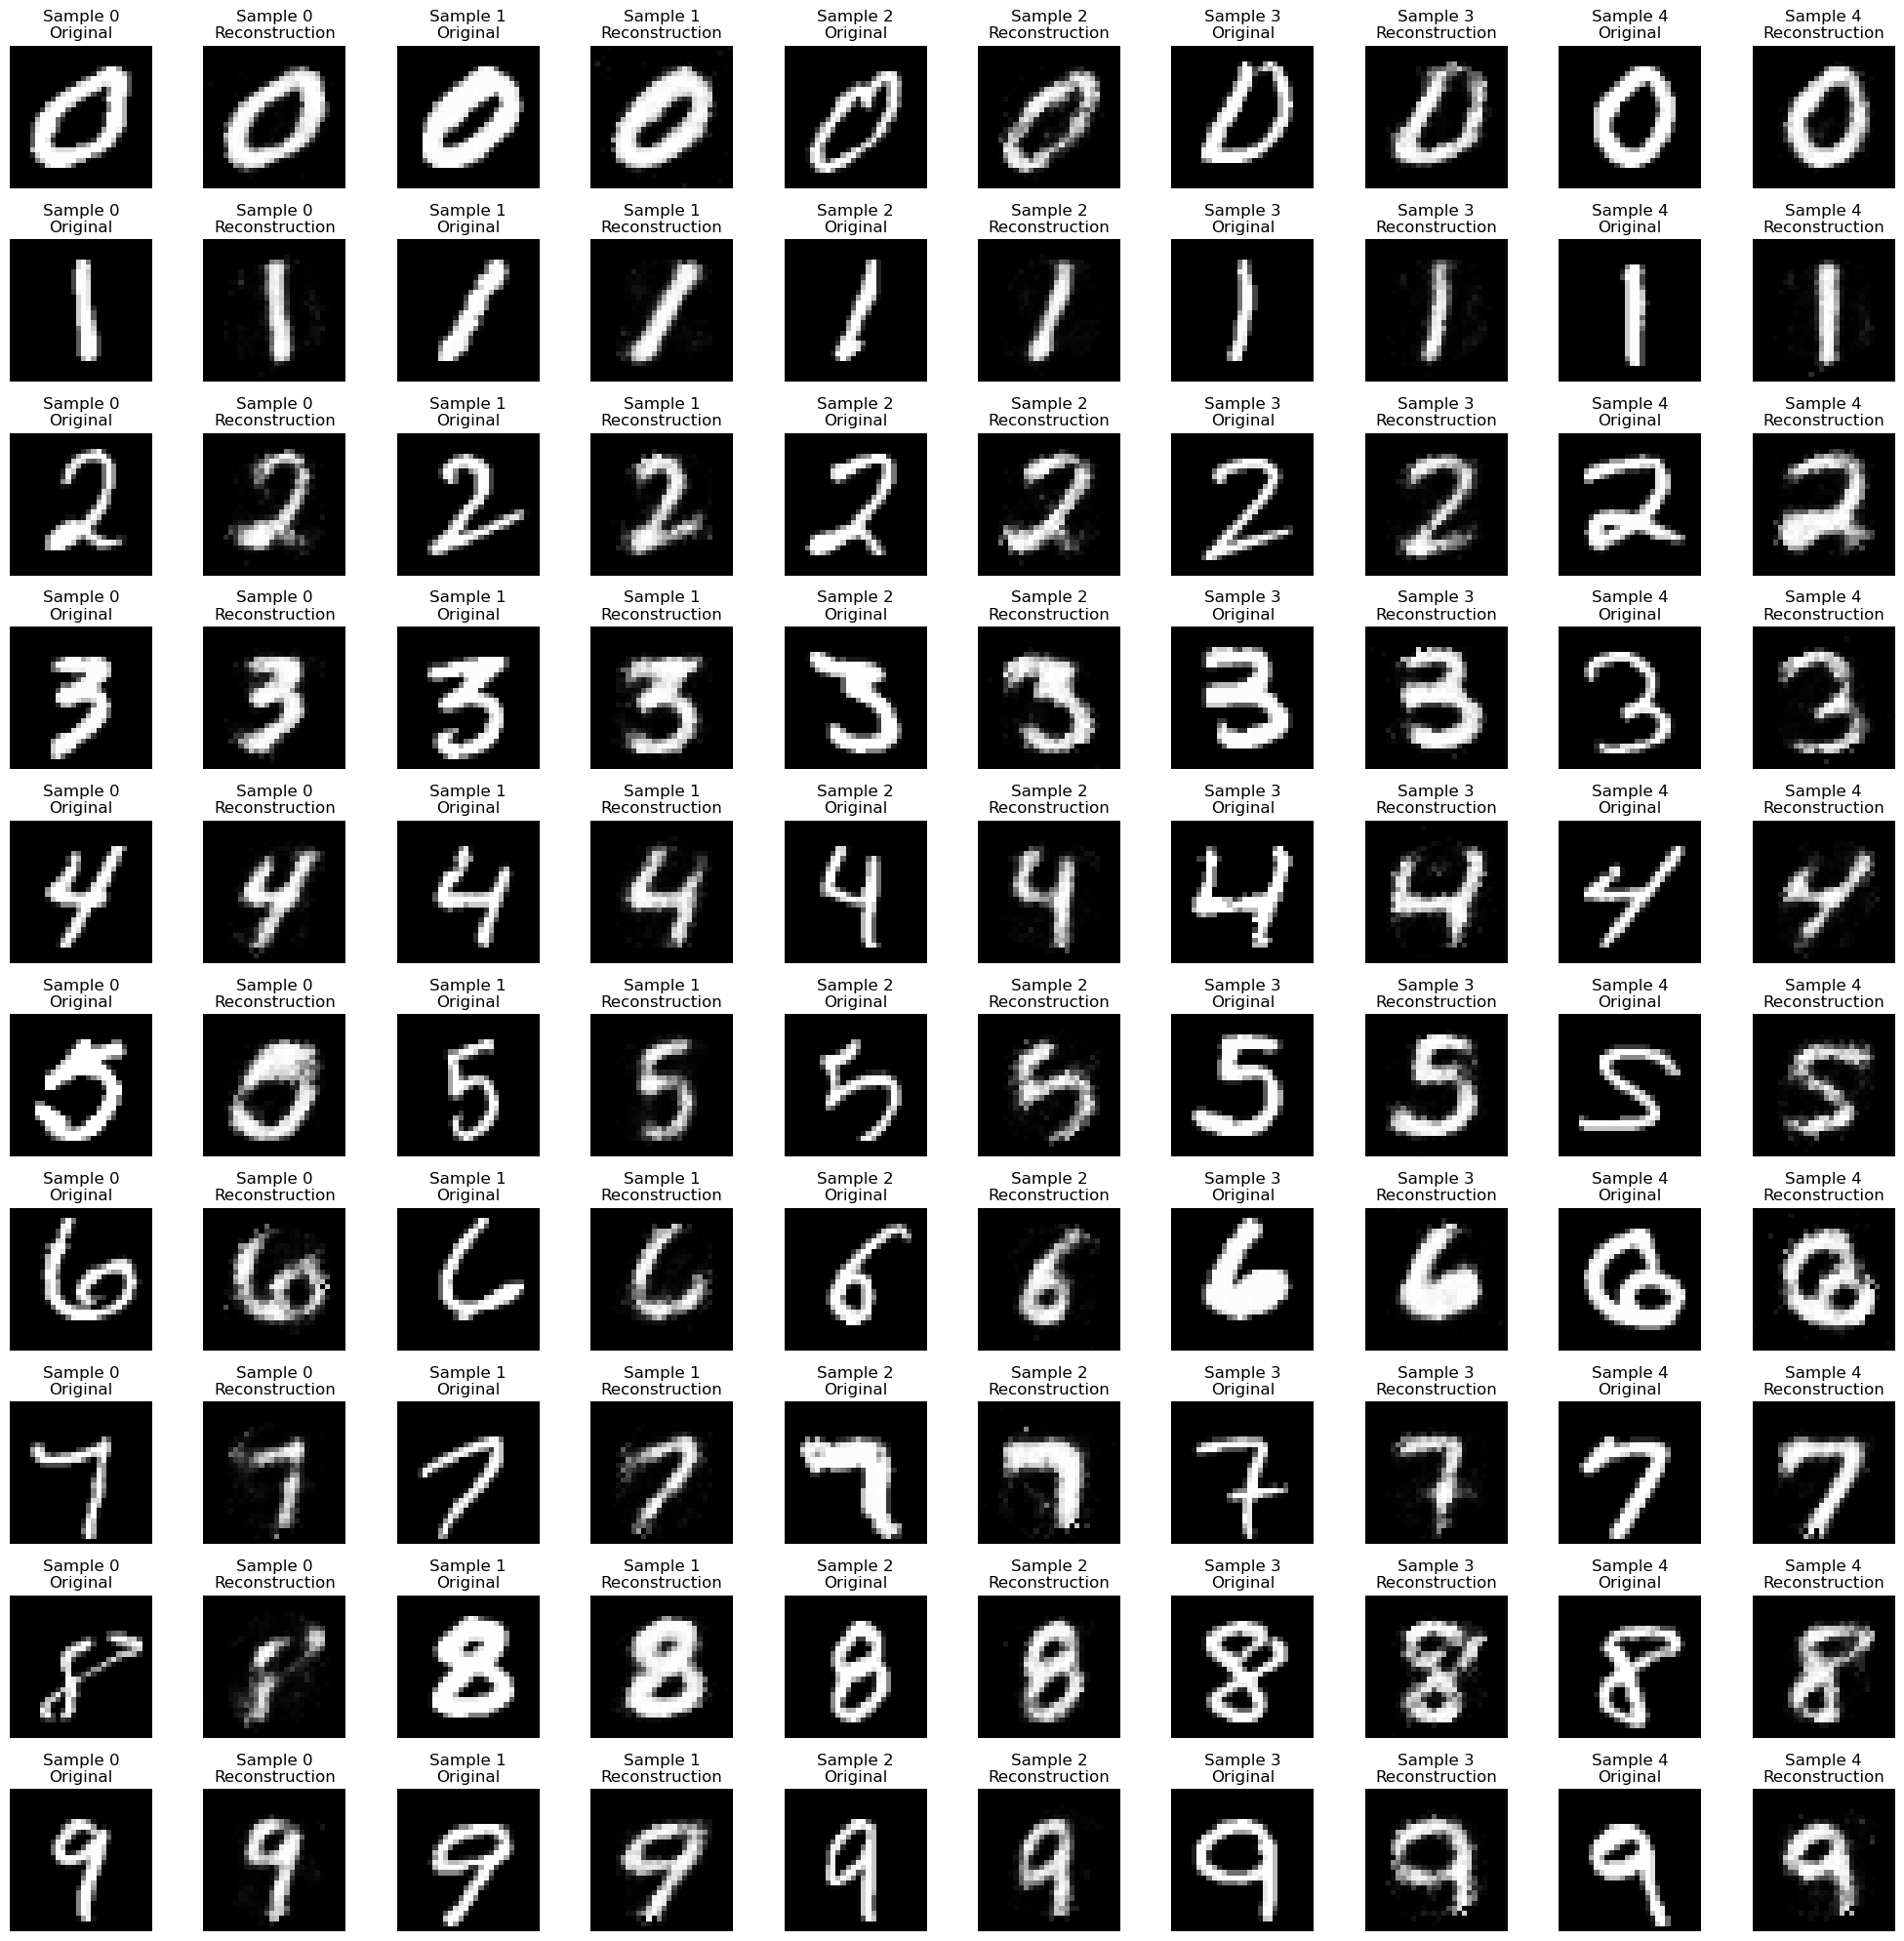

In [119]:
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

fig, axes = plt.subplots(10, 10, figsize=(20, 20))

model.eval()
with torch.no_grad():
    for i, images in samples.items():
        input = torch.stack(images).to(device).view(n, -1)
        reconstructions = model(input).view(-1, 28, 28).cpu()

        for j in range(n):
            img_ori = images[j].squeeze() * 0.5 + 0.5
            axes[i, 2*j].imshow(img_ori, cmap='grey')
            axes[i, 2*j].axis('off')
            axes[i, 2*j].set_title(f"Sample {j}\nOriginal", fontsize=12)

            img_rec = reconstructions[j] * 0.5 + 0.5
            axes[i, 2*j+1].imshow(img_rec, cmap='grey')
            axes[i, 2*j+1].axis('off')
            axes[i, 2*j+1].set_title(f"Sample {j}\nReconstruction", fontsize=12)

    plt.tight_layout()
    plt.show()